In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df=pd.read_csv('final_dataset.csv')

In [25]:
df.sample(3)

,Unnamed: 0,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,...,umpire2,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players
535,535,Indian Premier League,2016,19.0,2016-04-24,Rajkot,Saurashtra Cricket Association Stadium,Gujarat Lions,Royal Challengers Bengaluru,Royal Challengers Bengaluru,...,BNJ Oxenford,KN Ananthapadmanabhan,A Deshmukh,T20,20,6,male,club,"DR Smith, BB McCullum, SK Raina, KD Karthik, R...","V Kohli, SR Watson, AB de Villiers, KL Rahul, ..."
870,870,Indian Premier League,2021,55.0,2021-10-08,Abu Dhabi,Zayed Cricket Stadium,Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians,...,VK Sharma,Unknown,UV Gandhe,T20,20,6,male,club,"RG Sharma, Ishan Kishan, HH Pandya, KA Pollard...","JJ Roy, Abhishek Sharma, MK Pandey, Mohammad N..."
964,964,Indian Premier League,2023,15.0,2023-04-10,Bengaluru,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Lucknow Super Giants,Lucknow Super Giants,...,A Nand Kishore,CB Gaffaney,M Kuppuraj,T20,20,6,male,club,"Anuj Rawat, V Kohli, F du Plessis, GJ Maxwell,...","A Mishra, KR Mayers, KL Rahul, DJ Hooda, KH Pa..."


### Univariate Analysis

#### Task 1: Identify the most successful franchises overall.

In [26]:
result=df.winner.value_counts().reset_index()
result

,winner,count
0,Mumbai Indians,155
1,Chennai Super Kings,148
2,Royal Challengers Bengaluru,143
3,Kolkata Knight Riders,140
4,Punjab Kings,126
5,Delhi Capitals,125
6,Rajasthan Royals,123
7,Sunrisers Hyderabad,102
8,Gujarat Titans,47
9,Lucknow Super Giants,34


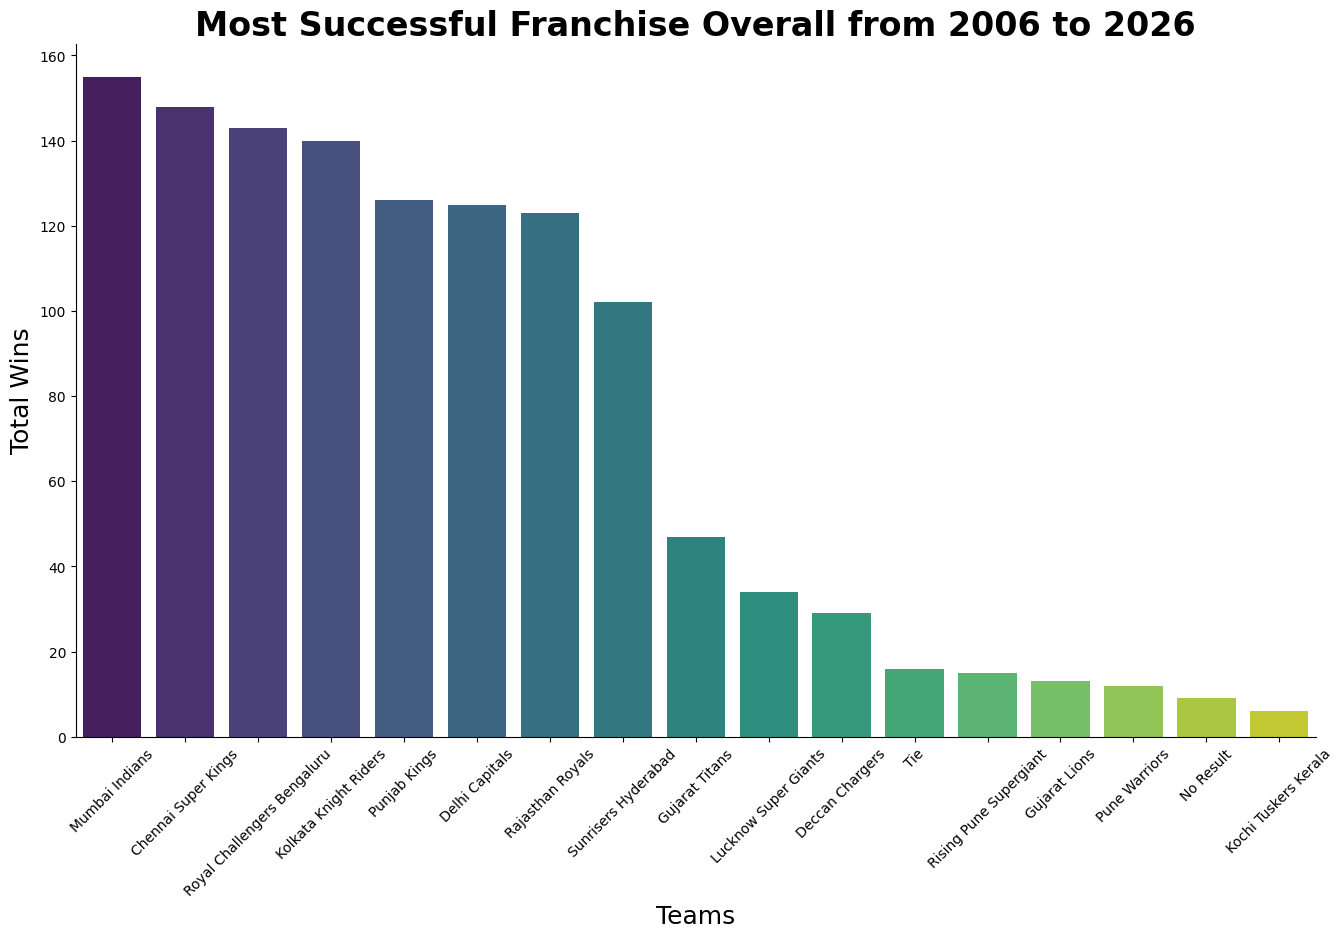

In [27]:
plt.subplots(figsize=(16,9))
sns.barplot( data=result, x='winner' , y='count' , palette='viridis',hue='winner' )
plt.title("Most Successful Franchise Overall from 2006 to 2026",fontsize=24,fontweight='bold')
plt.xlabel("Teams",fontsize=18)
plt.ylabel("Total Wins",fontsize=18)
plt.xticks(rotation = 45)

sns.despine()

#### Task 2: Find the most valuable players.

In [28]:
df['player_of_match'].value_counts().head(10)

player_of_match
AB de Villiers    25
CH Gayle          22
V Kohli           22
RG Sharma         21
SP Narine         18
DA Warner         18
MS Dhoni          18
RA Jadeja         17
KL Rahul          17
SR Watson         16
Name: count, dtype: int64

#### Task 3: Analyze the preferred toss decision.

In [29]:
df['toss_decision'].value_counts()*100/df.shape[0] # Field is more preferred

toss_decision
field    66.371681
bat      33.628319
Name: count, dtype: float64

### Bivariate Analysis

#### Task 4: The Toss Advantage. Does winning the toss actually translate to winning the match?

In [30]:
round(df[df['winner']==df['toss_winner']].shape[0]*100/df.shape[0],2)  # Not likely but it does give you an very little advantage 

50.52

#### Task 5: Defending vs. Chasing. Is it easier to win by setting a target or chasing one?

In [31]:
decisive_matches = df[~df['result_type'].isin(['tie','no result'])]

defending =decisive_matches[decisive_matches['win_by_runs'] > 0].shape[0] * 100 / decisive_matches.shape[0]
chasing = decisive_matches[decisive_matches['win_by_wickets'] > 0].shape[0] * 100 / decisive_matches.shape[0]

print(f"Defending Win Rate: {round(defending,2)}%")
print(f"Chasing Win Rate: {round(chasing,2)}%")

# So, According to the Analysis Chasing a target gives an advantage

Defending Win Rate: 45.81%
Chasing Win Rate: 54.19%


#### Task 6: Toss strategy evolution over the years.

In [32]:
result=df.groupby(['season','toss_decision'])['winner'].count().unstack()

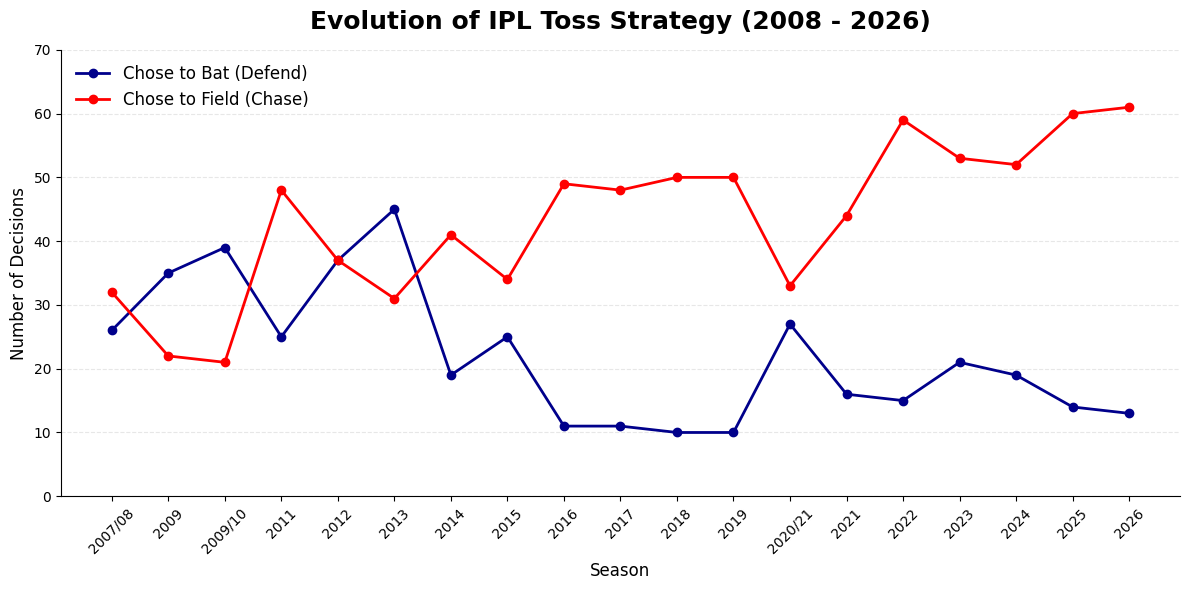

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(result.index, result['bat'], color='darkblue', marker='o', linewidth=2, label='Chose to Bat (Defend)')
ax.plot(result.index, result['field'], color='red', marker='o', linewidth=2, label='Chose to Field (Chase)')


ax.set_title("Evolution of IPL Toss Strategy (2008 - 2026)", fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Season', fontsize=12, color='black')
ax.set_ylabel('Number of Decisions', fontsize=12, color='black')
ax.set_ylim(0, 70)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(result.index, rotation=45)
plt.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

#### Task 7: Venue Characteristics (Batting Paradises vs Bowling Pitches).

In [34]:
venue_counts = df['venue'].value_counts()
valid_venues = venue_counts[venue_counts >= 20].index
filtered_venues_df = df[df['venue'].isin(valid_venues)]

venue_scoring = filtered_venues_df.groupby('venue')['team1_runs'].mean().sort_values(ascending=False).reset_index()
overall_avg = filtered_venues_df['team1_runs'].mean()

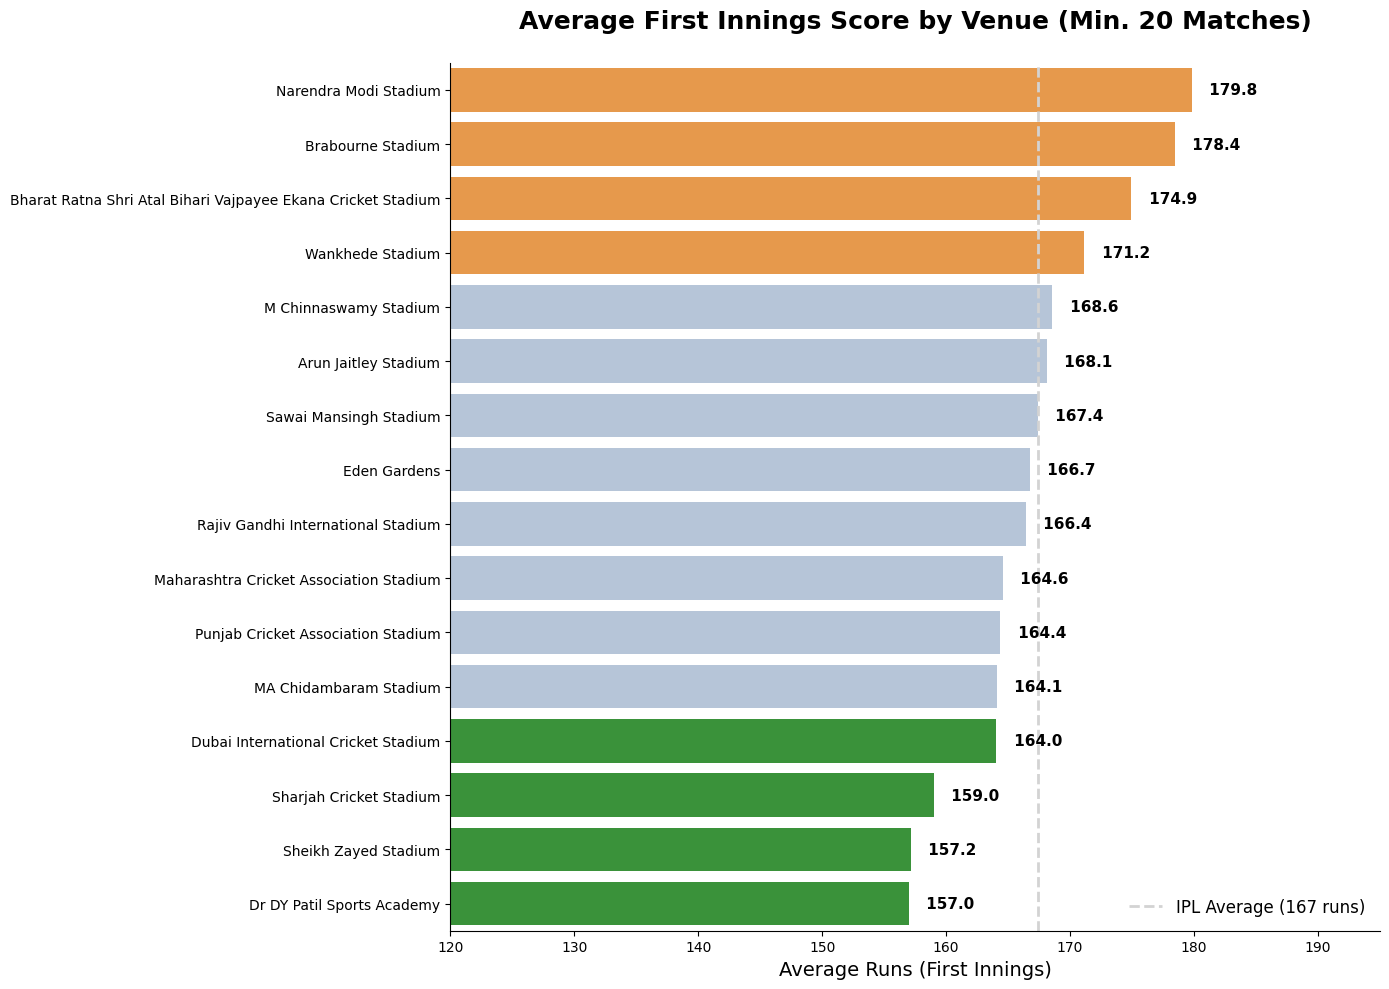

In [35]:
fig, ax = plt.subplots(figsize=(14, 10))

colors = ["#FF9933"]*4  + ['#b0c4de']*(len(venue_scoring)-8) + ['#2ca02c']*4

bars = sns.barplot(data=venue_scoring, x='team1_runs', y='venue', hue='venue',ax=ax,palette=colors,legend=False)

ax.axvline(overall_avg, color='lightgrey', linestyle='--', linewidth=2, label=f'IPL Average ({overall_avg:.0f} runs)')

for i, v in enumerate(venue_scoring['team1_runs']):
    ax.text(v + 1, i, f" {round(v,1)}", va='center', fontsize=11, fontweight='bold', color='black')

ax.set_title("Average First Innings Score by Venue (Min. 20 Matches)", fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel("Average Runs (First Innings)", fontsize=14)
ax.set_ylabel("")
ax.set_xlim(120, 195) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

#### Task 8: Fortress Stadiums. Which teams have the highest win percentage in their home cities?

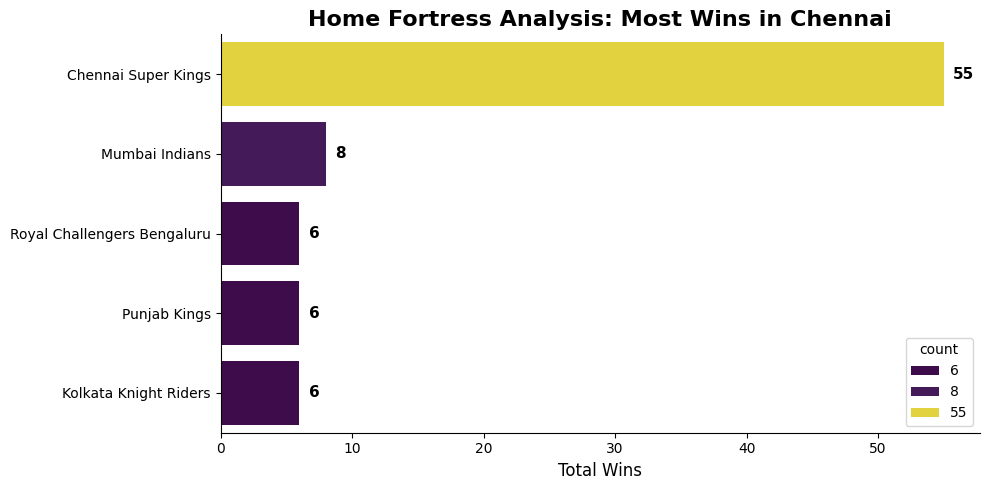

In [36]:
def analyze_fortress(city_name):
    city_matches = df[df['city'] == city_name]
    
    if city_matches.empty:
        return f"No matches found in the dataset for {city_name}."
    
    wins = city_matches['winner'].value_counts().head(5)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=wins.values, y=wins.index, palette='viridis', ax=ax,hue=wins)
    
    ax.set_title(f"Home Fortress Analysis: Most Wins in {city_name}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Total Wins", fontsize=12)
    ax.set_ylabel("")
    
    for i, v in enumerate(wins.values):
        ax.text(v + 0.7, i, str(v), va='center',fontsize=11, fontweight='bold')
        
    sns.despine()
    plt.tight_layout()
    plt.show()


analyze_fortress('Chennai')


#### Task 9: Ultimate Rivalries (Head-to-Head).

--- HEAD-TO-HEAD: Mumbai Indians vs Chennai Super Kings ---
Total Decisive Matches Played: 41

Mumbai Indians: 21 Wins (51.2%)
Chennai Super Kings: 20 Wins (48.8%)


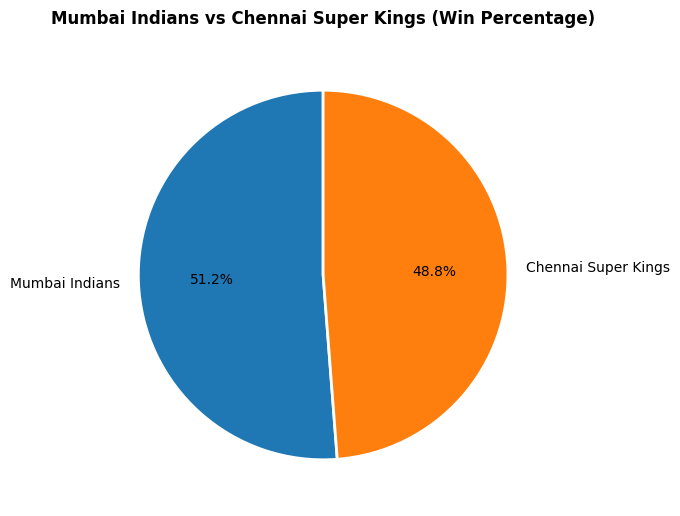

In [38]:
def analyze_rivalry(team_A, team_B):
    rivalry_df = df[((df['team1'] == team_A) & (df['team2'] == team_B)) | 
                    ((df['team1'] == team_B) & (df['team2'] == team_A))]
    
    if rivalry_df.empty:
        return f"No head-to-head matches found between {team_A} and {team_B}."
    
    wins = rivalry_df['winner'].value_counts()
    total_matches = wins.sum()
    
    print(f"--- HEAD-TO-HEAD: {team_A} vs {team_B} ---")
    print(f"Total Decisive Matches Played: {total_matches}\n")
    
    for team, count in wins.items():
        win_pct = (count / total_matches) * 100
        print(f"{team}: {count} Wins ({win_pct:.1f}%)")
        
    fig, ax = plt.subplots(figsize=(6, 6))
    
    colors = ['#1f77b4', '#ff7f0e'] 
    
    ax.pie(wins, labels=wins.index, autopct='%1.1f%%', startangle=90, 
           colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    
    ax.set_title(f"{team_A} vs {team_B} (Win Percentage)", fontweight='bold', pad=15)
    plt.show()


analyze_rivalry('Mumbai Indians', 'Chennai Super Kings')

### Conclusion

After a comprehensive exploratory data analysis of the IPL match dataset (2008–2026), several definitive trends and strategic realities emerged:

Franchise Dynasties: The Mumbai Indians (155 wins) and Chennai Super Kings (148 wins) stand as the undisputed titans of the league, significantly outpacing all other franchises in total victories. AB de Villiers leads individual brilliance with an unmatched 25 Player of the Match awards.

The Toss Illusion: Winning the coin toss provides virtually no statistical advantage, with the historical win rate for toss-winners hovering at a mere 50.5%.

Chasing is King: While the toss itself is a coin flip, the subsequent decision is critical. Historically, teams that bowl first and chase a target win more frequently (~53%) compared to teams defending a total (~45%). This statistical reality is reflected in captaincy decisions, with the preference to field first drastically increasing as the tournament evolved.

Pitch Characteristics: Venues heavily dictate match dynamics. Stadiums like the Narendra Modi Stadium and Brabourne Stadium act as extreme batting paradises (averaging nearly 180 runs in the first innings), whereas pitches like Sharjah and Dr DY Patil heavily suppress run-scoring.

The Chepauk Fortress: The concept of "home advantage" is most heavily pronounced in Chennai, where the Chennai Super Kings have secured 55 victories—nearly seven times more than the next most successful visiting franchise.

The Ultimate Rivalry: In the clash of the titans between MI and CSK, the Mumbai Indians hold a microscopic historical edge (51.2% win rate across 41 encounters), underscoring just how evenly matched the league's top two teams remain.